# Assignment 2: Identifying Rice Areas

**Integrantes**

- Max Chipani
- Julio Molina
- Irina Valenzuela

**Fase actual:** Fase 3 — clustering final k=2, validación Weka–scikit-learn,
áreas y ráster categórico corregido. Las etiquetas aún son neutrales.

## 2. Consigna y objetivo

El objetivo general es identificar áreas de arroz en Bellavista (San Martín)
mediante clustering no supervisado de embeddings AlphaEarth y validación
posterior con GloRice-I. Esta primera fase se limita a construir y validar una
muestra reproducible de píxeles agrícolas.

En esta fase no se ejecutan Clustergram, selección de `k`, K-Means final,
GloRice-I ni el análisis de incendios.

## 3. Entorno y reproducibilidad

El notebook está diseñado para ejecutarse desde la raíz del repositorio con el
entorno Conda `geoagent2`. No contiene instalaciones, credenciales, tokens ni
rutas absolutas.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from importlib import metadata
from pathlib import Path
import hashlib
import json
import math
import platform
import time

import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import netCDF4
import numpy as np
import pandas as pd
import pyarrow
import rasterio
import sklearn
import xarray as xr

# Cada usuario puede sustituir este valor por su propio proyecto habilitado
# para Google Earth Engine.
EE_PROJECT = "geoagent-assignment-2"

REPO_ROOT = Path.cwd()
ASSIGNMENT_DIR = REPO_ROOT / "Assignments" / "Assignment2"
OUTPUT_DIR = ASSIGNMENT_DIR / "outputs_grupo3"
CACHE_DIR = ASSIGNMENT_DIR / "cache_grupo3"
GEE_CACHE_DIR = CACHE_DIR / "raw" / "gee"
MANIFEST_DIR = CACHE_DIR / "manifests"
TMP_DIR = CACHE_DIR / "tmp"

for directory in (OUTPUT_DIR, GEE_CACHE_DIR, MANIFEST_DIR, TMP_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CSV_PATH = GEE_CACHE_DIR / "alphaearth_bellavista_cropland_sample_2019.csv"
PARQUET_PATH = GEE_CACHE_DIR / "alphaearth_bellavista_cropland_sample_2019.parquet"
MANIFEST_PATH = MANIFEST_DIR / "phase1_manifest.json"

BANDS = [f"A{i:02d}" for i in range(64)]
SAMPLE_SIZE = 10_000
SAMPLE_SCALE_M = 10
SAMPLE_SEED = 42
TILE_SCALE = 8
PHASE1_STARTED = time.perf_counter()
EXECUTED_AT_UTC = datetime.now(timezone.utc)

package_names = [
    "earthengine-api", "geemap", "clustergram", "netCDF4",
    "scikit-learn", "xarray", "rasterio", "geopandas",
    "pandas", "numpy", "matplotlib", "pyarrow",
]
environment_versions = {
    name: metadata.version(name) for name in package_names
}
environment_versions["python"] = platform.python_version()

pd.DataFrame(
    {"package": list(environment_versions), "version": list(environment_versions.values())}
)

,package,version
0,earthengine-api,1.7.36
1,geemap,0.38.3
2,clustergram,0.8.1
3,netCDF4,1.7.4
4,scikit-learn,1.9.0
5,xarray,2026.7.0
6,rasterio,1.5.0
7,geopandas,1.1.4
8,pandas,3.0.3
9,numpy,2.5.1


## 4. Fuentes de datos

- Región: `FAO/GAUL/2015/level2`.
- Embeddings: `GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`.
- Máscara agrícola: imagen `ESA/WorldCover/v200/2021`, banda `Map`, clase 40.

Los 64 valores `A00`–`A63` son las únicas variables que entrarán al clustering.
La máscara, coordenadas, geometrías e identificadores no forman parte de `X`.

## 5. Limitaciones temporales

AlphaEarth resume las condiciones de **2019**, mientras que WorldCover v200
representa **2021**. WorldCover se usa exclusivamente como máscara espacial de
cropland; no se interpreta como referencia de arroz ni como evidencia temporal
de cultivo en 2019.

## 6. Inicialización de Earth Engine

In [2]:
ee.Initialize(project=EE_PROJECT)
ee_probe = ee.Number(1).getInfo()
assert ee_probe == 1
print(f"Earth Engine inicializado correctamente con el proyecto: {EE_PROJECT}")

Earth Engine inicializado correctamente con el proyecto: geoagent-assignment-2


## 7. Región de Bellavista

In [3]:
gaul2 = ee.FeatureCollection("FAO/GAUL/2015/level2")
selected = (
    gaul2
    .filter(ee.Filter.eq("ADM1_NAME", "San Martín"))
    .filter(ee.Filter.eq("ADM2_NAME", "Bellavista"))
)

region_count = int(selected.size().getInfo())
if region_count != 1:
    raise RuntimeError(
        f"Bellavista debe devolver exactamente una entidad; se obtuvieron {region_count}."
    )

geometry = selected.geometry()
region_area_km2 = float(geometry.area(maxError=1).divide(1e6).getInfo())
if not math.isfinite(region_area_km2) or region_area_km2 <= 0:
    raise RuntimeError("La geometría de Bellavista está vacía o tiene área inválida.")

region_properties = (
    selected.first()
    .toDictionary(["ADM0_NAME", "ADM1_NAME", "ADM2_NAME"])
    .getInfo()
)
region_bounds = geometry.bounds(maxError=1).coordinates().getInfo()

REGION_SUMMARY = {
    "feature_count": region_count,
    "territorial_name": region_properties,
    "area_km2": region_area_km2,
    "bounds": region_bounds,
}
print(json.dumps(REGION_SUMMARY, ensure_ascii=False, indent=2))

{
  "feature_count": 1,
  "territorial_name": {
    "ADM0_NAME": "Peru",
    "ADM1_NAME": "San Martín",
    "ADM2_NAME": "Bellavista"
  },
  "area_km2": 7823.890636174687,
  "bounds": [
    [
      [
        -76.72772059259887,
        -8.382597192415476
      ],
      [
        -75.83685914684455,
        -8.382597192415476
      ],
      [
        -75.83685914684455,
        -6.725604127574741
      ],
      [
        -76.72772059259887,
        -6.725604127574741
      ],
      [
        -76.72772059259887,
        -8.382597192415476
      ]
    ]
  ]
}


## 8. AlphaEarth 2019

In [4]:
ALPHAEARTH_DATASET = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
START_DATE = "2019-01-01"
END_DATE = "2020-01-01"

embedding_collection = (
    ee.ImageCollection(ALPHAEARTH_DATASET)
    .filterDate(START_DATE, END_DATE)
    .filterBounds(geometry)
)
embedding_image_count = int(embedding_collection.size().getInfo())
if embedding_image_count == 0:
    raise RuntimeError("La colección AlphaEarth 2019 está vacía en Bellavista.")

alphaearth_utm_zones = embedding_collection.aggregate_array("UTM_ZONE").distinct().getInfo()
if alphaearth_utm_zones != ["18S"]:
    raise RuntimeError(
        "Los tiles AlphaEarth que cubren Bellavista no comparten la zona UTM "
        f"esperada 18S: {alphaearth_utm_zones}"
    )

reference_image = ee.Image(embedding_collection.first()).select(BANDS)
reference_projection = reference_image.select("A00").projection()
embeddingsImage = (
    embedding_collection
    .mosaic()
    .select(BANDS)
    .setDefaultProjection(reference_projection)
    .clip(geometry)
)
observed_bands = embeddingsImage.bandNames().getInfo()
if observed_bands != BANDS:
    raise RuntimeError(
        "Las bandas AlphaEarth no coinciden exactamente con A00–A63 en el orden esperado."
    )

reference_crs = reference_projection.crs().getInfo()
nominal_scale_m = float(reference_projection.nominalScale().getInfo())
if reference_crs != "EPSG:32718" or not math.isclose(
    nominal_scale_m, 10.0, rel_tol=0, abs_tol=1e-9
):
    raise RuntimeError(
        f"Proyección AlphaEarth inesperada: {reference_crs}, {nominal_scale_m} m."
    )

valid_embedding_area_m2 = float(
    ee.Image.pixelArea()
    .updateMask(embeddingsImage.select("A00").mask())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=SAMPLE_SCALE_M,
        maxPixels=1e11,
        tileScale=TILE_SCALE,
    )
    .get("area")
    .getInfo()
)
embedding_coverage_pct = 100 * valid_embedding_area_m2 / (region_area_km2 * 1e6)

ALPHAEARTH_SUMMARY = {
    "dataset": ALPHAEARTH_DATASET,
    "period": [START_DATE, END_DATE],
    "image_count": embedding_image_count,
    "band_count": len(observed_bands),
    "bands": observed_bands,
    "nominal_scale_m": nominal_scale_m,
    "reference_crs": reference_crs,
    "utm_zones": alphaearth_utm_zones,
    "valid_coverage_pct_of_bellavista": embedding_coverage_pct,
    "additional_normalization": False,
}
print(json.dumps(ALPHAEARTH_SUMMARY, ensure_ascii=False, indent=2))

{
  "dataset": "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL",
  "period": [
    "2019-01-01",
    "2020-01-01"
  ],
  "image_count": 4,
  "band_count": 64,
  "bands": [
    "A00",
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09",
    "A10",
    "A11",
    "A12",
    "A13",
    "A14",
    "A15",
    "A16",
    "A17",
    "A18",
    "A19",
    "A20",
    "A21",
    "A22",
    "A23",
    "A24",
    "A25",
    "A26",
    "A27",
    "A28",
    "A29",
    "A30",
    "A31",
    "A32",
    "A33",
    "A34",
    "A35",
    "A36",
    "A37",
    "A38",
    "A39",
    "A40",
    "A41",
    "A42",
    "A43",
    "A44",
    "A45",
    "A46",
    "A47",
    "A48",
    "A49",
    "A50",
    "A51",
    "A52",
    "A53",
    "A54",
    "A55",
    "A56",
    "A57",
    "A58",
    "A59",
    "A60",
    "A61",
    "A62",
    "A63"
  ],
  "nominal_scale_m": 10.0,
  "reference_crs": "EPSG:32718",
  "utm_zones": [
    "18S"
  ],
  "valid_coverage_pct_of_bellavista": 

## 9. WorldCover y máscara cropland

In [5]:
WORLDCOVER_DATASET = "ESA/WorldCover/v200/2021"
worldcover = ee.Image(WORLDCOVER_DATASET).select("Map").clip(geometry)
croplandMask = worldcover.eq(40).rename("cropmask")

cropland_area_m2 = float(
    ee.Image.pixelArea()
    .updateMask(croplandMask)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=SAMPLE_SCALE_M,
        maxPixels=1e11,
        tileScale=TILE_SCALE,
    )
    .get("area")
    .getInfo()
)
cropland_area_km2 = cropland_area_m2 / 1e6
cropland_pct = 100 * cropland_area_km2 / region_area_km2

CROPLAND_SUMMARY = {
    "dataset": WORLDCOVER_DATASET,
    "band": "Map",
    "class_value": 40,
    "class_name": "Cropland",
    "bellavista_area_km2": region_area_km2,
    "cropland_area_km2": cropland_area_km2,
    "cropland_pct_of_bellavista": cropland_pct,
    "temporal_mismatch": {
        "alphaearth_year": 2019,
        "worldcover_year": 2021,
    },
    "use": "spatial cropland mask only; not a rice reference",
}
print(json.dumps(CROPLAND_SUMMARY, ensure_ascii=False, indent=2))

{
  "dataset": "ESA/WorldCover/v200/2021",
  "band": "Map",
  "class_value": 40,
  "class_name": "Cropland",
  "bellavista_area_km2": 7823.890636174687,
  "cropland_area_km2": 186.78628729220992,
  "cropland_pct_of_bellavista": 2.3873836685367427,
  "temporal_mismatch": {
    "alphaearth_year": 2019,
    "worldcover_year": 2021
  },
  "use": "spatial cropland mask only; not a rice reference"
}


## 10. Muestreo de embeddings

La máscara contiene una única clase válida (`cropland`), por lo que
un muestreo dirigido de la única clase válida evita que el factor aproximado de
`ee.Image.sample` se calcule sobre los píxeles no agrícolas de toda Bellavista.
Por ello se usa `stratifiedSample` únicamente para obtener exactamente 10,000
píxeles de la clase 1. `cropmask` se elimina inmediatamente después del muestreo
y no forma parte de la matriz de variables. La geometría se conserva únicamente
para control espacial.

In [6]:
clusterImage = embeddingsImage.updateMask(croplandMask).select(BANDS)
sampling_image = clusterImage.addBands(croplandMask)

sample_with_mask_fc = sampling_image.stratifiedSample(
    numPoints=0,
    classBand="cropmask",
    region=geometry,
    scale=SAMPLE_SCALE_M,
    projection=reference_projection,
    seed=SAMPLE_SEED,
    classValues=[1],
    classPoints=[SAMPLE_SIZE],
    dropNulls=True,
    tileScale=TILE_SCALE,
    geometries=True,
)

sample_mask_histogram = sample_with_mask_fc.aggregate_histogram("cropmask").getInfo()
sample_cropland_count = int(sample_mask_histogram.get("1", 0))
if sample_cropland_count != SAMPLE_SIZE or len(sample_mask_histogram) != 1:
    raise RuntimeError(
        "La muestra dirigida no contiene exclusivamente 10,000 observaciones "
        f"cropmask == 1: {sample_mask_histogram}"
    )

# cropmask se usa únicamente para dirigir y validar el muestreo. Se elimina
# antes de la transferencia y nunca entra en la matriz X.
sample_fc = sample_with_mask_fc.select(BANDS)

sample_server_count = int(sample_fc.size().getInfo())
if sample_server_count != SAMPLE_SIZE:
    raise RuntimeError(
        f"Se solicitaron {SAMPLE_SIZE} muestras, pero Earth Engine generó "
        f"{sample_server_count}. No se reducirá el tamaño silenciosamente."
    )

download_method = "geemap.ee_to_gdf via ee.data.computeFeatures"
fallback_export = None

try:
    sample_gdf = geemap.ee_to_gdf(sample_fc)
except Exception as direct_error:
    def add_coordinates(feature):
        coordinates = feature.geometry().coordinates()
        return feature.set(
            {
                "sample_lon": coordinates.get(0),
                "sample_lat": coordinates.get(1),
            }
        )

    export_fc = sample_fc.map(add_coordinates)
    export_task = ee.batch.Export.table.toDrive(
        collection=export_fc,
        description="Assignment2_Phase1_AlphaEarth_Bellavista_2019",
        folder="GeoAgent_Assignment2",
        fileNamePrefix="alphaearth_bellavista_cropland_sample_2019",
        fileFormat="CSV",
        selectors=BANDS + ["sample_lon", "sample_lat"],
    )
    export_task.start()
    fallback_export = export_task.status()
    fallback_manifest = {
        "status": "DIRECT_TRANSFER_FAILED",
        "error_type": type(direct_error).__name__,
        "error": str(direct_error),
        "task": fallback_export,
        "requested_samples": SAMPLE_SIZE,
    }
    MANIFEST_PATH.write_text(
        json.dumps(fallback_manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    raise RuntimeError(
        "La transferencia directa falló. Se creó una tarea controlada de "
        f"Export.table.toDrive con task ID {fallback_export.get('id')}. "
        "Complete la descarga y reanude la fase."
    ) from direct_error

missing_downloaded_bands = [band for band in BANDS if band not in sample_gdf.columns]
if missing_downloaded_bands:
    raise RuntimeError(
        f"La transferencia no contiene todas las bandas: {missing_downloaded_bands}"
    )
if sample_gdf.geometry.isna().any():
    raise RuntimeError("La muestra contiene geometrías nulas.")

sample_gdf = sample_gdf.to_crs("EPSG:4326")
sample_df = sample_gdf[BANDS].copy()
sample_df["sample_lon"] = sample_gdf.geometry.x.to_numpy()
sample_df["sample_lat"] = sample_gdf.geometry.y.to_numpy()
sample_df = sample_df.sort_values(
    ["sample_lat", "sample_lon"], kind="mergesort"
).reset_index(drop=True)

sample_df.to_csv(CSV_PATH, index=False, float_format="%.17g")
sample_df.to_parquet(PARQUET_PATH, index=False, engine="pyarrow")

print(f"Método de transferencia: {download_method}")
print(f"Muestras guardadas: {len(sample_df):,}")
print(f"CSV: {CSV_PATH.relative_to(REPO_ROOT)}")
print(f"Parquet: {PARQUET_PATH.relative_to(REPO_ROOT)}")

Método de transferencia: geemap.ee_to_gdf via ee.data.computeFeatures
Muestras guardadas: 10,000
CSV: Assignments\Assignment2\cache_grupo3\raw\gee\alphaearth_bellavista_cropland_sample_2019.csv
Parquet: Assignments\Assignment2\cache_grupo3\raw\gee\alphaearth_bellavista_cropland_sample_2019.parquet


## 11. Clustergram y selección de k

<!-- phase2_clustergram_selection -->

Se evalúa `k = 1…11` con Clustergram 0.8.1
y backend `sklearn`, ajustando K-Means directamente sobre los 64 embeddings
AlphaEarth originales `A00–A63`. No se aplican StandardScaler, normalización,
PCA, UMAP ni selección de variables. La proyección PC1 del Clustergram es
exclusivamente visual.


In [10]:
from contextlib import redirect_stdout
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from clustergram import Clustergram
from IPython.display import Image as NotebookImage
from pyproj import Transformer
import io
import re

PHASE2_DERIVED_DIR = CACHE_DIR / "derived"
PHASE2_MANIFEST_DIR = CACHE_DIR / "manifests"
PHASE2_INPUT_PATH = (
    CACHE_DIR / "raw" / "gee"
    / "alphaearth_bellavista_cropland_sample_2019.parquet"
)
PHASE2_METRICS_PATH = PHASE2_DERIVED_DIR / "cluster_metrics_k_2_11.parquet"
PHASE2_LABELS_PATH = PHASE2_DERIVED_DIR / "cluster_labels_k_1_11.parquet"
PHASE2_CENTERS_PATH = PHASE2_DERIVED_DIR / "cluster_centers_k_1_11.parquet"
PHASE2_SIZES_PATH = PHASE2_DERIVED_DIR / "cluster_sizes_k_1_11.parquet"
PHASE2_SILHOUETTE_INDICES_PATH = (
    PHASE2_DERIVED_DIR / "silhouette_indices_seed42.npy"
)
PHASE2_CLUSTERGRAM_FIGURE = OUTPUT_DIR / "clustergram_k_selection.png"
PHASE2_STABILITY_SUMMARY_PATH = (
    PHASE2_DERIVED_DIR / "cluster_stability_summary_candidates.parquet"
)
PHASE2_STABILITY_PAIRWISE_PATH = (
    PHASE2_DERIVED_DIR / "cluster_stability_pairwise_candidates.parquet"
)
PHASE2_STABILITY_SIZES_PATH = (
    PHASE2_DERIVED_DIR / "cluster_stability_sizes_candidates.parquet"
)
PHASE2_SPATIAL_PATH = (
    PHASE2_DERIVED_DIR / "cluster_spatial_coherence_candidates.parquet"
)
PHASE2_SPATIAL_FIGURE = (
    PHASE2_DERIVED_DIR / "cluster_spatial_diagnostic_candidates.png"
)
PHASE2_DECISION_PATH = (
    PHASE2_DERIVED_DIR / "cluster_candidate_decision_table.parquet"
)

PHASE2_K_RANGE = list(range(1, 12))
PHASE2_CANDIDATES = [2, 3, 4]
PHASE2_SEEDS = [42, 52, 62]
PHASE2_KMEANS_PARAMETERS = {
    "init": "k-means++",
    "n_init": 20,
    "random_state": 42,
    "max_iter": 300,
    "algorithm": "lloyd",
}

PHASE2_DERIVED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
phase2_sample = pd.read_parquet(PHASE2_INPUT_PATH)
X_PHASE2 = phase2_sample[BANDS].copy()
if X_PHASE2.shape != (10_000, 64) or list(X_PHASE2.columns) != BANDS:
    raise RuntimeError("X_PHASE2 no contiene exactamente 10,000 × A00–A63.")
if X_PHASE2.isna().to_numpy().any():
    raise RuntimeError("X_PHASE2 contiene nulos.")
X_PHASE2_ARRAY = X_PHASE2.to_numpy(dtype=np.float64)
if not np.isfinite(X_PHASE2_ARRAY).all():
    raise RuntimeError("X_PHASE2 contiene valores no finitos.")
if X_PHASE2.duplicated().any():
    raise RuntimeError("X_PHASE2 contiene duplicados exactos.")

phase2_norms = np.linalg.norm(X_PHASE2_ARRAY, axis=1)
print(f"Entrada: {PHASE2_INPUT_PATH.relative_to(REPO_ROOT)}")
print(f"X_PHASE2: {X_PHASE2.shape}; columnas: {BANDS[0]}–{BANDS[-1]}")
print(
    "Normas sin modificar — "
    f"mín={phase2_norms.min():.6f}, "
    f"media={phase2_norms.mean():.6f}, "
    f"máx={phase2_norms.max():.6f}"
)
print(f"Clustergram: {metadata.version('clustergram')}")
print(f"scikit-learn: {metadata.version('scikit-learn')}")
print(PHASE2_KMEANS_PARAMETERS)

Entrada: Assignments\Assignment2\cache_grupo3\raw\gee\alphaearth_bellavista_cropland_sample_2019.parquet
X_PHASE2: (10000, 64); columnas: A00–A63
Normas sin modificar — mín=0.993008, media=1.000083, máx=1.007869
Clustergram: 0.8.1
scikit-learn: 1.9.0
{'init': 'k-means++', 'n_init': 20, 'random_state': 42, 'max_iter': 300, 'algorithm': 'lloyd'}


Checkpoints de Clustergram reutilizados; no se repitió el ajuste.


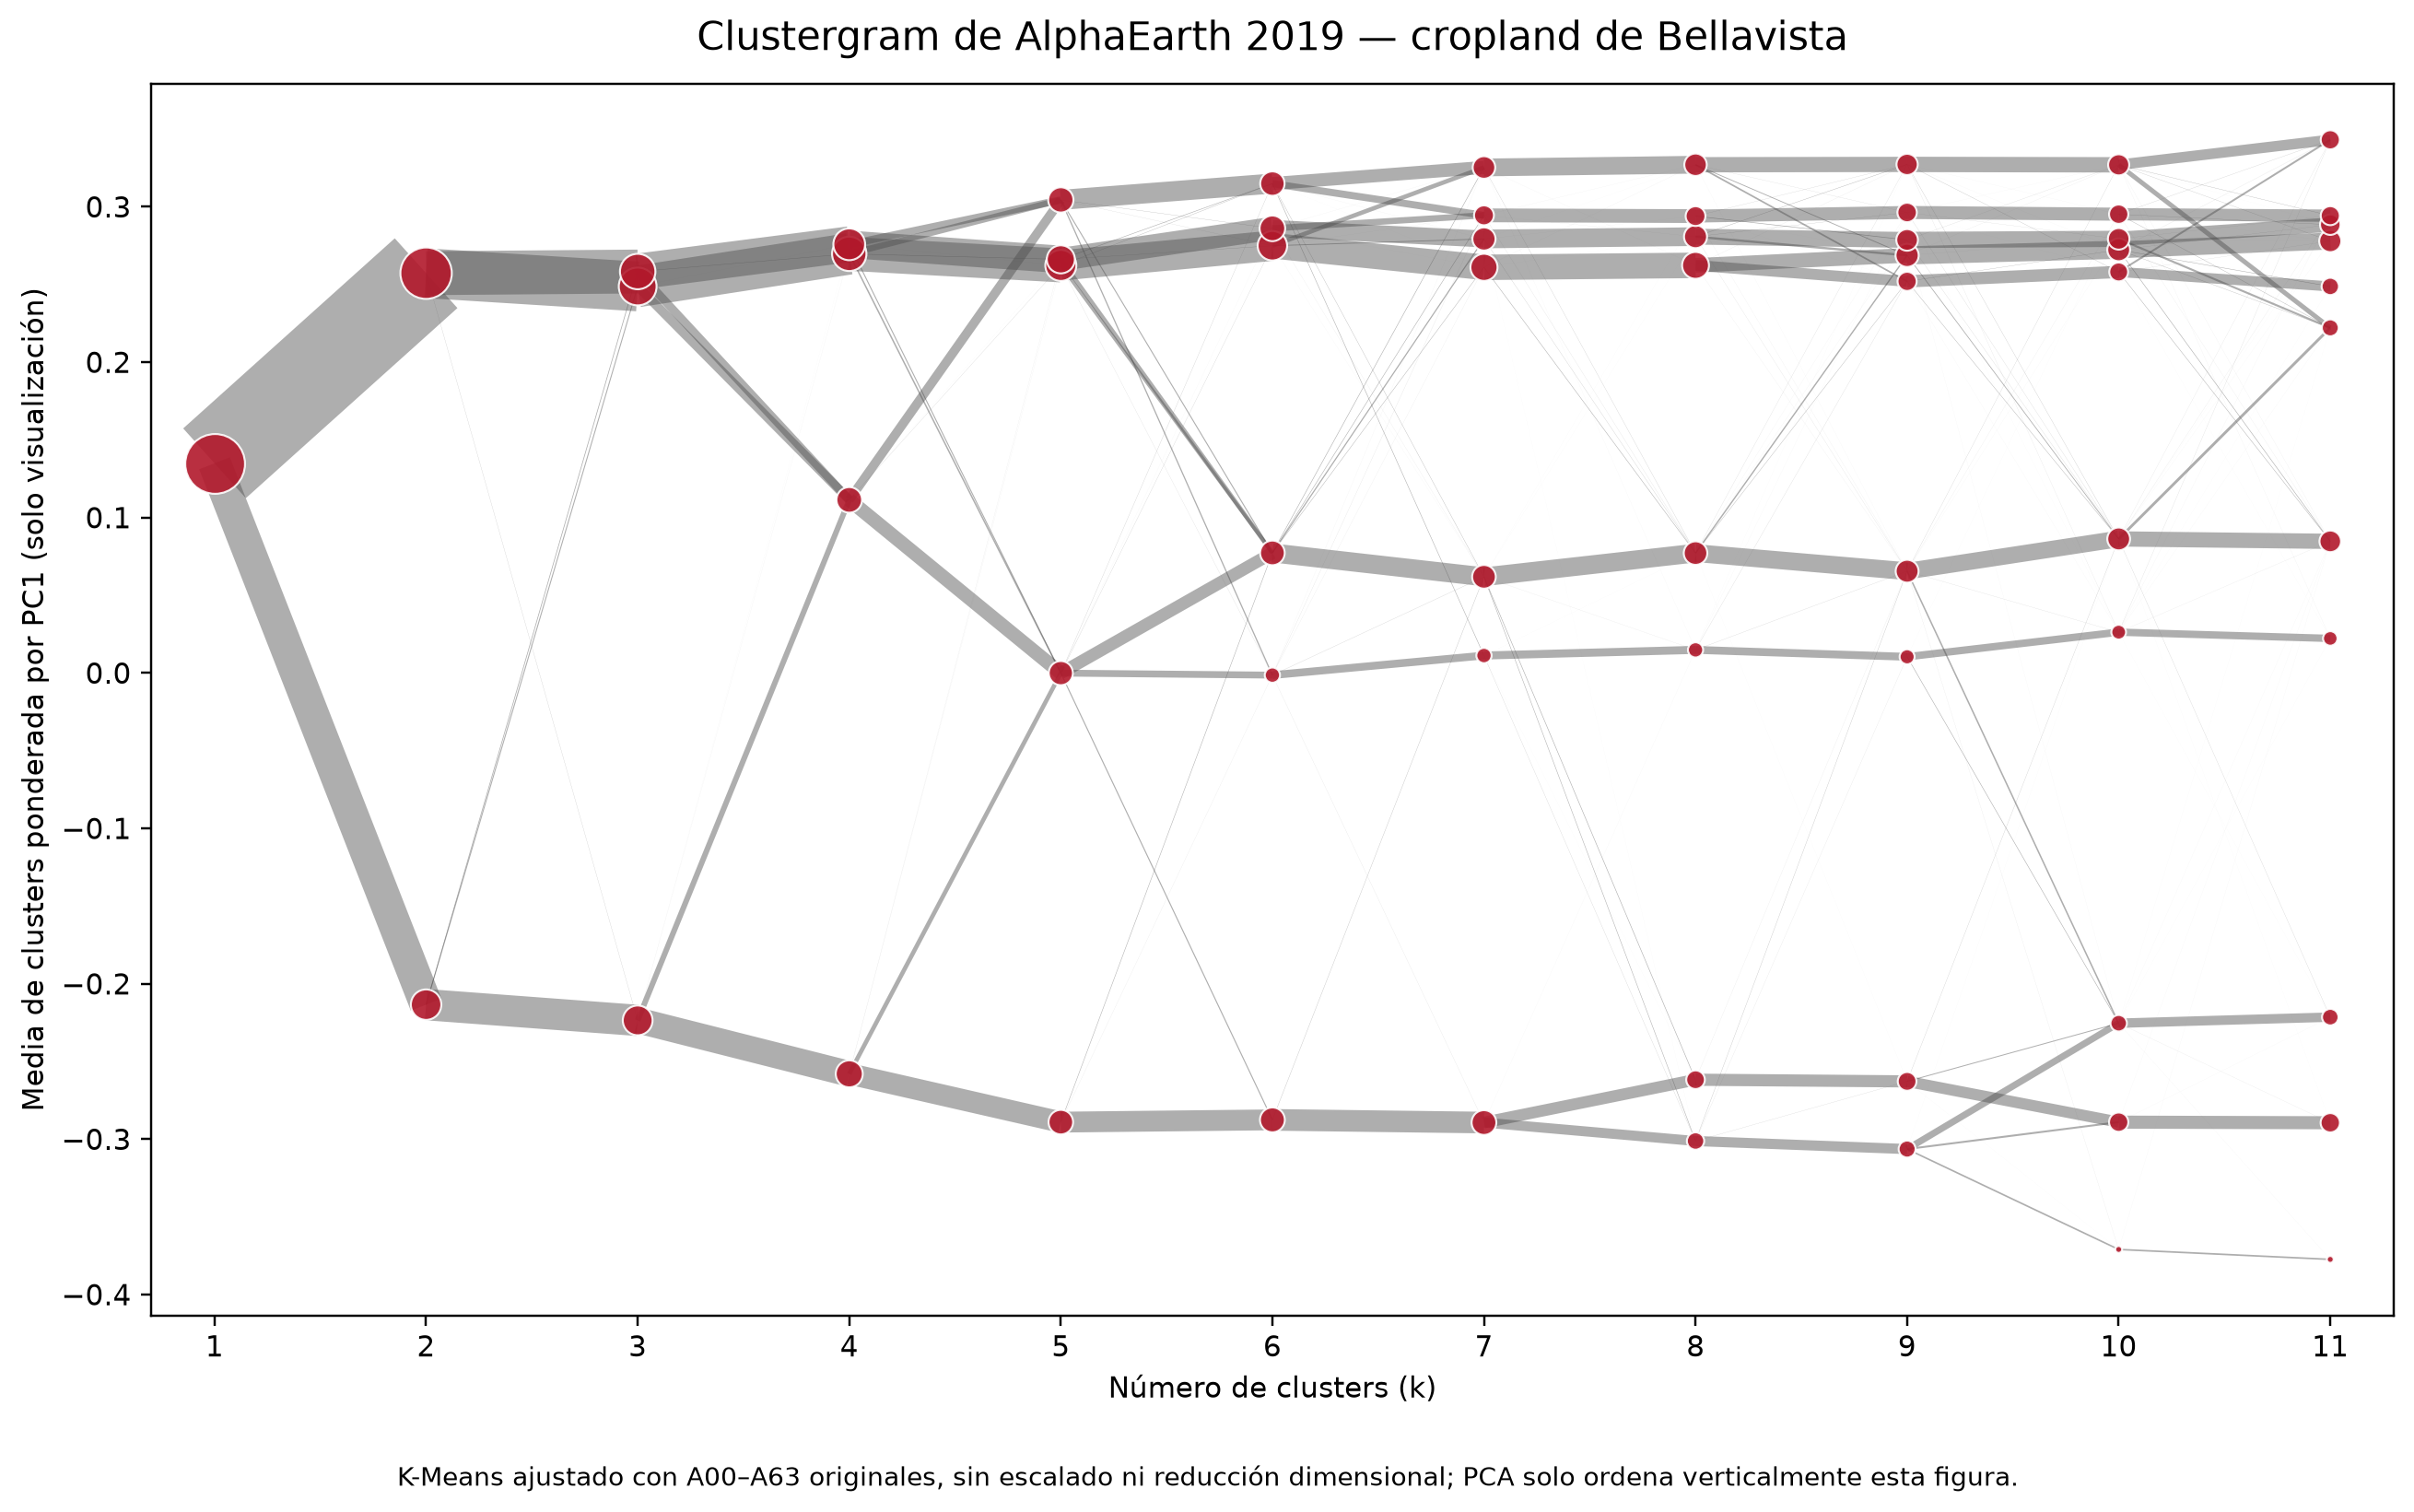

,k,fit_seconds,inertia,silhouette_sample_2000,calinski_harabasz,davies_bouldin,minimum_cluster_size,maximum_cluster_size,minimum_cluster_proportion,maximum_cluster_proportion,clusters_below_1_percent
0,2,1.133,1540.376,0.2509,2779.280,1.6628,2599,7401,0.2599,0.7401,0
1,3,0.506,1360.726,0.1619,2232.878,1.9668,2481,4000,0.2481,0.4000,0
2,4,0.711,1268.775,0.1549,1837.786,1.9644,1826,3306,0.1826,0.3306,0
3,5,1.252,1211.751,0.1268,1560.648,2.1020,1627,2694,0.1627,0.2694,0
4,6,1.669,1160.486,0.1320,1391.838,2.0061,648,2432,0.0648,0.2432,0
5,7,1.507,1122.191,0.1162,1256.163,2.0846,650,2055,0.0650,0.2055,0
6,8,1.734,1087.944,0.1092,1155.426,2.2320,645,2016,0.0645,0.2016,0
7,9,2.727,1056.997,0.1024,1077.058,2.2197,626,1498,0.0626,0.1498,0
8,10,1.750,1027.688,0.1048,1016.247,2.1114,132,1454,0.0132,0.1454,0
9,11,2.250,1004.365,0.1070,958.966,2.1045,132,1365,0.0132,0.1365,0


In [11]:
core_cache = [
    PHASE2_METRICS_PATH,
    PHASE2_LABELS_PATH,
    PHASE2_CENTERS_PATH,
    PHASE2_SIZES_PATH,
    PHASE2_SILHOUETTE_INDICES_PATH,
    PHASE2_CLUSTERGRAM_FIGURE,
]

if not all(path.exists() for path in core_cache):
    phase2_cgram = Clustergram(
        k_range=PHASE2_K_RANGE,
        backend="sklearn",
        method="kmeans",
        verbose=True,
        **PHASE2_KMEANS_PARAMETERS,
    )
    fit_log = io.StringIO()
    with redirect_stdout(fit_log):
        phase2_cgram.fit(X_PHASE2)
    print(fit_log.getvalue())
    fit_seconds_by_k = {1: 0.0}
    for match in re.finditer(
        r"K=(\d+) fitted in ([0-9.]+) seconds",
        fit_log.getvalue(),
    ):
        fit_seconds_by_k[int(match.group(1))] = float(match.group(2))

    phase2_labels = pd.DataFrame({
        f"k_{k}": phase2_cgram.labels_[k].to_numpy(dtype=np.int16)
        for k in PHASE2_K_RANGE
    })
    center_rows = []
    for k in PHASE2_K_RANGE:
        for cluster_id, center in enumerate(phase2_cgram.cluster_centers_[k]):
            row = {"k": k, "cluster_id": cluster_id}
            row.update(dict(zip(BANDS, np.asarray(center, dtype=float), strict=True)))
            center_rows.append(row)
    phase2_centers = pd.DataFrame(center_rows)

    rng = np.random.default_rng(42)
    silhouette_indices = np.sort(
        rng.choice(len(X_PHASE2), size=2_000, replace=False)
    )
    size_rows, metric_rows = [], []
    for k in PHASE2_K_RANGE:
        labels_k = phase2_labels[f"k_{k}"].to_numpy(dtype=np.int32)
        counts = np.bincount(labels_k, minlength=k)
        for cluster_id, count in enumerate(counts):
            size_rows.append({
                "k": k,
                "cluster_id": cluster_id,
                "size": int(count),
                "percentage": float(count / len(X_PHASE2) * 100),
                "below_1_percent": bool(count / len(X_PHASE2) < 0.01),
            })
        if k >= 2:
            centers_k = np.asarray(phase2_cgram.cluster_centers_[k])
            residuals = X_PHASE2_ARRAY - centers_k[labels_k]
            metric_rows.append({
                "k": k,
                "fit_seconds": float(fit_seconds_by_k.get(k, np.nan)),
                "inertia": float(np.einsum("ij,ij->", residuals, residuals)),
                "silhouette_sample_2000": float(silhouette_score(
                    X_PHASE2_ARRAY[silhouette_indices],
                    labels_k[silhouette_indices],
                )),
                "calinski_harabasz": float(
                    calinski_harabasz_score(X_PHASE2_ARRAY, labels_k)
                ),
                "davies_bouldin": float(
                    davies_bouldin_score(X_PHASE2_ARRAY, labels_k)
                ),
                "minimum_cluster_size": int(counts.min()),
                "maximum_cluster_size": int(counts.max()),
                "minimum_cluster_proportion": float(counts.min() / len(X_PHASE2)),
                "maximum_cluster_proportion": float(counts.max() / len(X_PHASE2)),
                "clusters_below_1_percent": int((counts / len(X_PHASE2) < 0.01).sum()),
            })
    phase2_metrics = pd.DataFrame(metric_rows)
    phase2_sizes = pd.DataFrame(size_rows)
    phase2_labels.to_parquet(PHASE2_LABELS_PATH, index=False)
    phase2_centers.to_parquet(PHASE2_CENTERS_PATH, index=False)
    phase2_metrics.to_parquet(PHASE2_METRICS_PATH, index=False)
    phase2_sizes.to_parquet(PHASE2_SIZES_PATH, index=False)
    np.save(PHASE2_SILHOUETTE_INDICES_PATH, silhouette_indices)

    fig, ax = plt.subplots(figsize=(12, 7.5))
    phase2_cgram.plot(
        ax=ax,
        size=0.9,
        linewidth=0.9,
        cluster_style={
            "color": "#b2182b",
            "edgecolor": "white",
            "linewidth": 0.7,
            "alpha": 0.9,
        },
        line_style={"color": "#4d4d4d", "alpha": 0.45},
        pca_weighted=True,
        pca_kwargs={"svd_solver": "full"},
        pca_component=1,
    )
    ax.set_xticks(PHASE2_K_RANGE)
    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Media de clusters ponderada por PC1 (solo visualización)")
    ax.set_title("Clustergram de AlphaEarth 2019 — cropland de Bellavista")
    fig.text(
        0.5,
        0.012,
        "A00–A63 originales; PCA solo para la proyección de la figura.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(PHASE2_CLUSTERGRAM_FIGURE, dpi=220, bbox_inches="tight")
    plt.close(fig)
else:
    phase2_labels = pd.read_parquet(PHASE2_LABELS_PATH)
    phase2_centers = pd.read_parquet(PHASE2_CENTERS_PATH)
    phase2_metrics = pd.read_parquet(PHASE2_METRICS_PATH)
    phase2_sizes = pd.read_parquet(PHASE2_SIZES_PATH)
    cached_labels = phase2_labels.rename(
        columns={f"k_{k}": k for k in PHASE2_K_RANGE}
    )
    cached_centers = {
        k: phase2_centers.loc[phase2_centers["k"] == k, BANDS].to_numpy()
        for k in PHASE2_K_RANGE
    }
    phase2_cgram = Clustergram.from_centers(
        cached_centers, cached_labels, data=X_PHASE2
    )
    print("Checkpoints de Clustergram reutilizados; no se repitió el ajuste.")

display(NotebookImage(filename=str(PHASE2_CLUSTERGRAM_FIGURE)))
display(
    phase2_metrics.style.format({
        "fit_seconds": "{:.3f}",
        "inertia": "{:.3f}",
        "silhouette_sample_2000": "{:.4f}",
        "calinski_harabasz": "{:.3f}",
        "davies_bouldin": "{:.4f}",
        "minimum_cluster_proportion": "{:.4f}",
        "maximum_cluster_proportion": "{:.4f}",
    })
)

### 11.1 Métricas y tamaños de clusters

Silhouette usa una única submuestra determinista de 2,000 observaciones
(`seed=42`) para todos los valores de `k`. Inercia, Calinski–Harabasz y
Davies–Bouldin usan las 10,000 observaciones. Un cluster inferior al 1% se
marca como advertencia, sin eliminarlo.


In [12]:
phase2_size_summary = (
    phase2_sizes.assign(
        cluster=lambda frame: frame["cluster_id"].map(lambda value: f"C{value}"),
        size_and_percentage=lambda frame: frame.apply(
            lambda row: f"{int(row['size']):,} ({row['percentage']:.2f}%)",
            axis=1,
        ),
    )
    .pivot(index="k", columns="cluster", values="size_and_percentage")
)
display(phase2_size_summary.fillna("—"))
small_phase2_clusters = phase2_sizes[phase2_sizes["below_1_percent"]]
print(
    "Clusters <1%: ninguno."
    if small_phase2_clusters.empty
    else "Advertencias <1%:"
)
if not small_phase2_clusters.empty:
    display(small_phase2_clusters)

cluster,C0,C1,C10,C2,C3,C4,C5,C6,C7,C8,C9
k,,,,,,,,,,,
1,"10,000 (100.00%)",—,—,—,—,—,—,—,—,—,—
2,"2,599 (25.99%)","7,401 (74.01%)",—,—,—,—,—,—,—,—,—
3,"2,481 (24.81%)","3,519 (35.19%)",—,"4,000 (40.00%)",—,—,—,—,—,—,—
4,"1,826 (18.26%)","2,829 (28.29%)",—,"2,039 (20.39%)","3,306 (33.06%)",—,—,—,—,—,—
5,"2,208 (22.08%)","2,694 (26.94%)",—,"1,688 (16.88%)","1,627 (16.27%)","1,783 (17.83%)",—,—,—,—,—
6,"1,698 (16.98%)","1,728 (17.28%)",—,"1,834 (18.34%)",648 (6.48%),"2,432 (24.32%)","1,660 (16.60%)",—,—,—,—
7,650 (6.50%),"1,103 (11.03%)",—,"1,713 (17.13%)","2,055 (20.55%)","1,494 (14.94%)","1,421 (14.21%)","1,564 (15.64%)",—,—,—
8,840 (8.40%),"1,409 (14.09%)",—,"2,016 (20.16%)",967 (9.67%),"1,551 (15.51%)","1,481 (14.81%)",645 (6.45%),"1,091 (10.91%)",—,—
9,626 (6.26%),"1,498 (14.98%)",—,"1,262 (12.62%)","1,460 (14.60%)",802 (8.02%),973 (9.73%),"1,054 (10.54%)","1,304 (13.04%)","1,021 (10.21%)",—


Clusters <1%: ninguno.


### 11.2 Estabilidad entre semillas

Los candidatos `k = 2, 3, 4` se comparan con semillas 42, 52 y 62 mediante
Adjusted Rand Index. Los tamaños se alinean contra la partición de semilla 42
mediante asignación húngara; no se eliminan observaciones ni clusters.


In [13]:
if all(path.exists() for path in (
    PHASE2_STABILITY_SUMMARY_PATH,
    PHASE2_STABILITY_PAIRWISE_PATH,
    PHASE2_STABILITY_SIZES_PATH,
)):
    phase2_stability_summary = pd.read_parquet(PHASE2_STABILITY_SUMMARY_PATH)
    phase2_stability_pairwise = pd.read_parquet(PHASE2_STABILITY_PAIRWISE_PATH)
    phase2_stability_sizes = pd.read_parquet(PHASE2_STABILITY_SIZES_PATH)
else:
    def align_partition(reference, candidate, k):
        contingency = np.zeros((k, k), dtype=np.int64)
        np.add.at(contingency, (reference, candidate), 1)
        reference_ids, candidate_ids = linear_sum_assignment(-contingency)
        mapping = {
            int(candidate_id): int(reference_id)
            for reference_id, candidate_id in zip(
                reference_ids, candidate_ids, strict=True
            )
        }
        return np.array(
            [mapping[int(label)] for label in candidate],
            dtype=np.int16,
        )

    stability_pair_rows, stability_size_rows, stability_summary_rows = [], [], []
    for k in PHASE2_CANDIDATES:
        partitions = {
            42: phase2_labels[f"k_{k}"].to_numpy(dtype=np.int16)
        }
        for seed in PHASE2_SEEDS[1:]:
            partitions[seed] = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=20,
                random_state=seed,
                max_iter=300,
                algorithm="lloyd",
            ).fit_predict(X_PHASE2).astype(np.int16)
        aligned = {42: partitions[42]}
        for seed in PHASE2_SEEDS[1:]:
            aligned[seed] = align_partition(
                partitions[42], partitions[seed], k
            )

        ari_values = []
        for seed_a, seed_b in combinations(PHASE2_SEEDS, 2):
            ari = float(adjusted_rand_score(
                aligned[seed_a], aligned[seed_b]
            ))
            ari_values.append(ari)
            stability_pair_rows.append({
                "k": k,
                "seed_a": seed_a,
                "seed_b": seed_b,
                "adjusted_rand_index": ari,
            })

        cluster_ranges = []
        for cluster_id in range(k):
            seed_sizes = {
                seed: int(np.count_nonzero(
                    aligned[seed] == cluster_id
                ))
                for seed in PHASE2_SEEDS
            }
            cluster_ranges.append(max(seed_sizes.values()) - min(seed_sizes.values()))
            for seed, size in seed_sizes.items():
                stability_size_rows.append({
                    "k": k,
                    "aligned_cluster_id": cluster_id,
                    "seed": seed,
                    "size": size,
                    "percentage": float(size / len(X_PHASE2) * 100),
                })
        stability_summary_rows.append({
            "k": k,
            "ari_mean": float(np.mean(ari_values)),
            "ari_minimum": float(np.min(ari_values)),
            "ari_maximum": float(np.max(ari_values)),
            "maximum_cluster_size_range": int(max(cluster_ranges)),
            "maximum_cluster_size_range_percentage_points": float(
                max(cluster_ranges) / len(X_PHASE2) * 100
            ),
            "mean_cluster_size_range": float(np.mean(cluster_ranges)),
        })

    phase2_stability_summary = pd.DataFrame(stability_summary_rows)
    phase2_stability_pairwise = pd.DataFrame(stability_pair_rows)
    phase2_stability_sizes = pd.DataFrame(stability_size_rows)
    phase2_stability_summary.to_parquet(
        PHASE2_STABILITY_SUMMARY_PATH, index=False
    )
    phase2_stability_pairwise.to_parquet(
        PHASE2_STABILITY_PAIRWISE_PATH, index=False
    )
    phase2_stability_sizes.to_parquet(
        PHASE2_STABILITY_SIZES_PATH, index=False
    )

display(
    phase2_stability_summary.style.format({
        "ari_mean": "{:.6f}",
        "ari_minimum": "{:.6f}",
        "ari_maximum": "{:.6f}",
        "maximum_cluster_size_range_percentage_points": "{:.2f}",
        "mean_cluster_size_range": "{:.2f}",
        **(
            {"total_additional_fit_seconds": "{:.3f}"}
            if "total_additional_fit_seconds" in phase2_stability_summary.columns
            else {}
        ),
    })
)
display(phase2_stability_pairwise)

,k,ari_mean,ari_minimum,ari_maximum,maximum_cluster_size_range,maximum_cluster_size_range_percentage_points,mean_cluster_size_range,total_additional_fit_seconds
0,2,1.000000,1.000000,1.000000,0,0.00,0.00,0.544
1,3,1.000000,1.000000,1.000000,0,0.00,0.00,1.051
2,4,0.986909,0.980704,0.995477,48,0.48,29.50,2.433


,k,seed_a,seed_b,adjusted_rand_index
0,2,42,52,1.000000
1,2,42,62,1.000000
2,2,52,62,1.000000
3,3,42,52,1.000000
4,3,42,62,1.000000
5,3,52,62,1.000000
6,4,42,52,0.980704
7,4,42,62,0.995477
8,4,52,62,0.984546


### 11.3 Diagnóstico espacial

Las coordenadas se incorporan únicamente después del ajuste y solo para
visualización y control de coherencia. No forman parte de `X`. Los colores son
IDs arbitrarios y no representan arroz ni no-arroz.


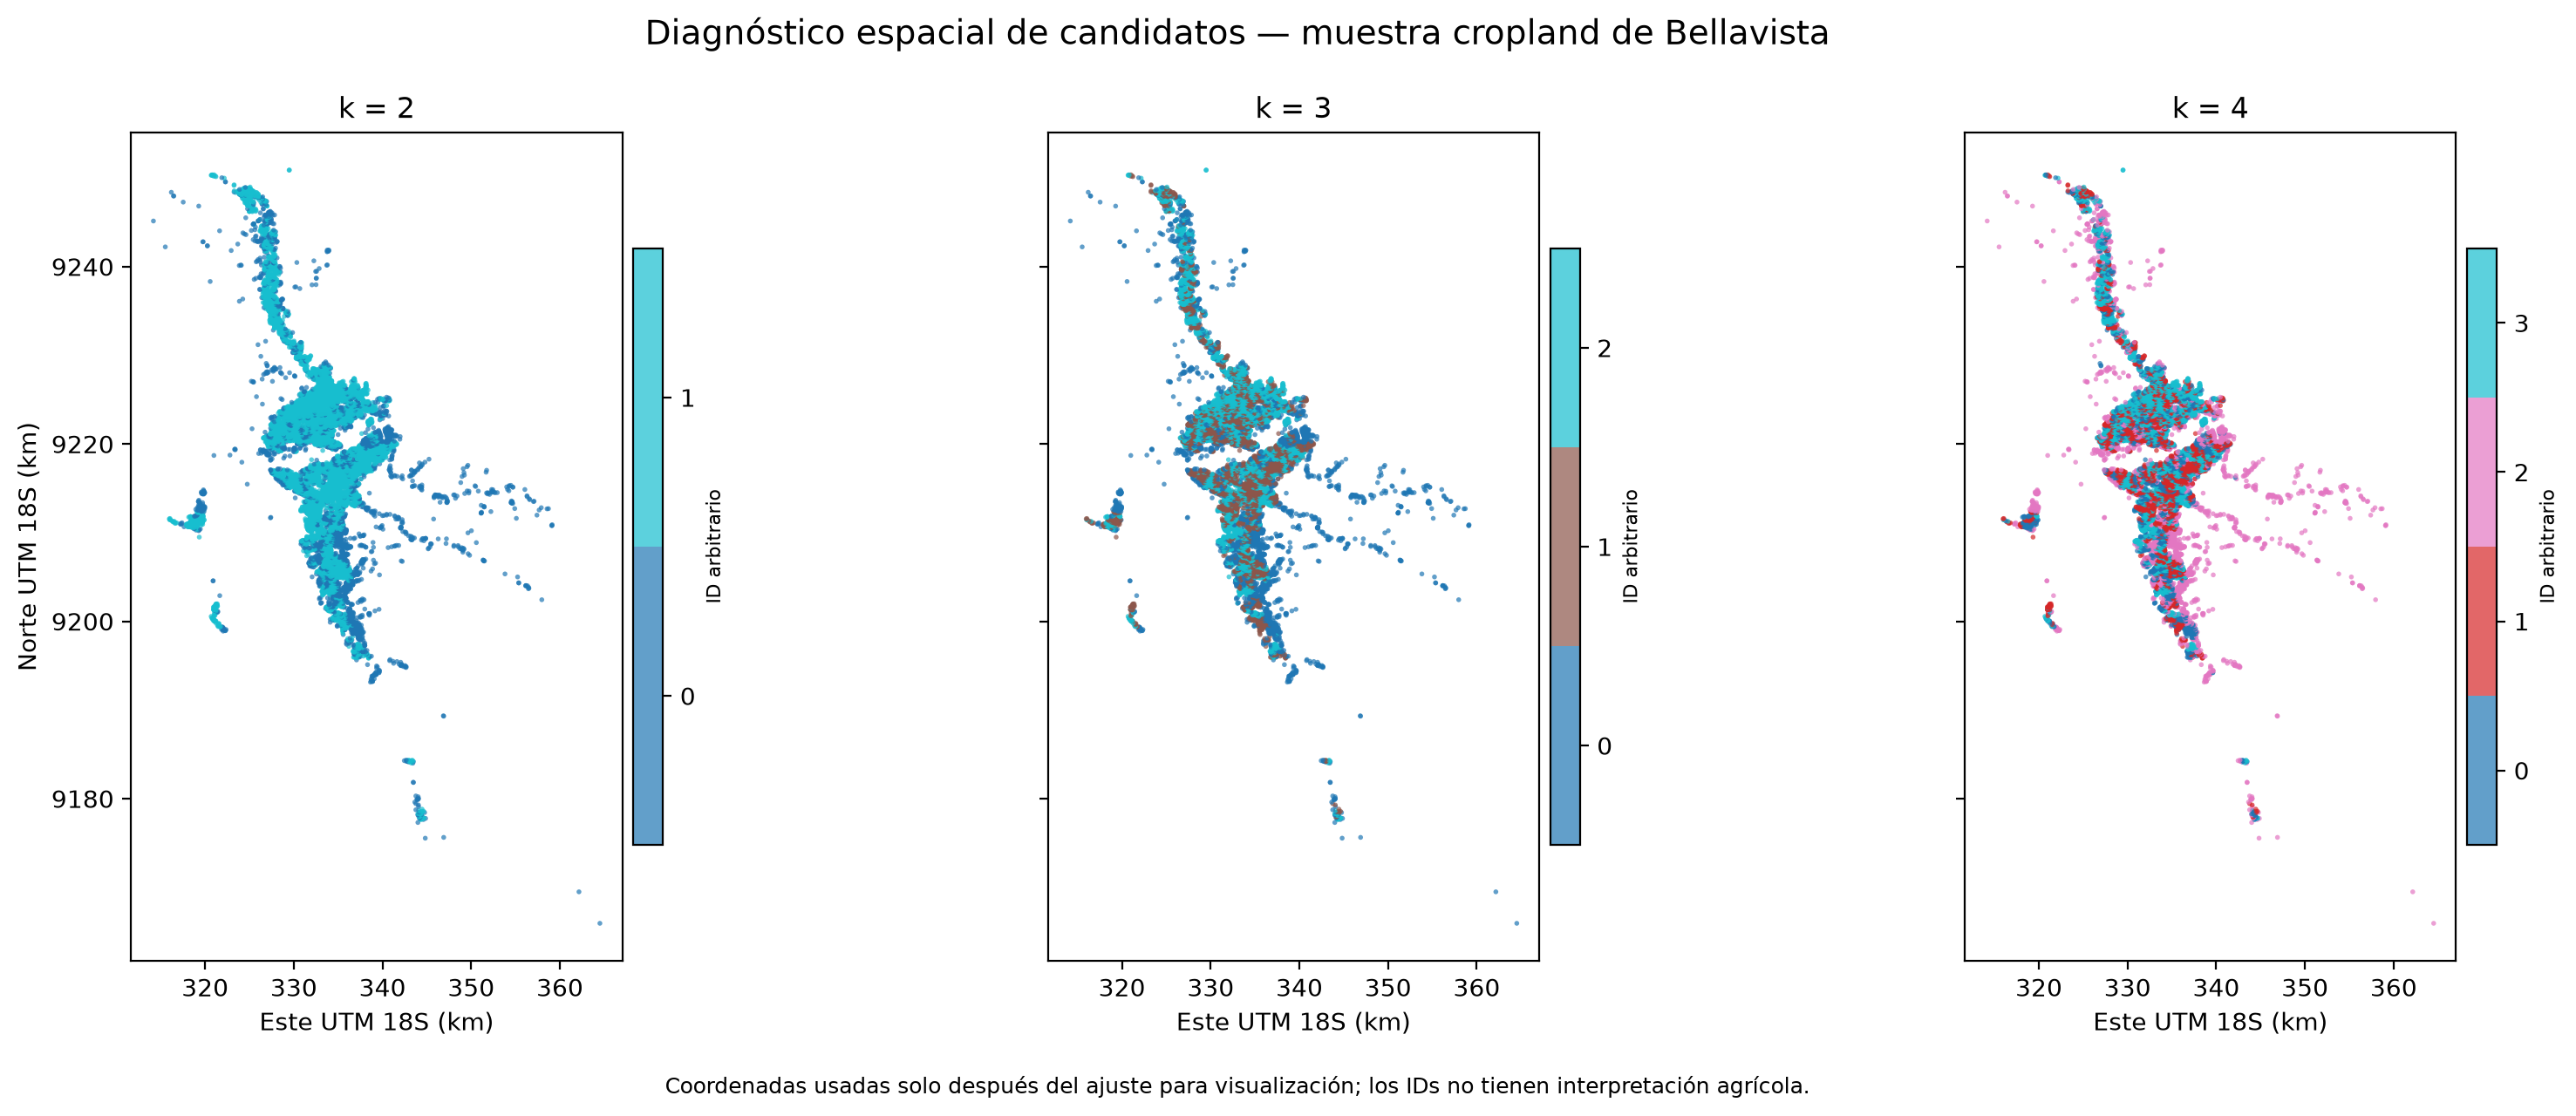

,k,mean_eight_neighbor_label_agreement,median_eight_neighbor_label_agreement,percentile_10,percentile_90,coordinates_used_as_model_input,coordinate_crs
0,2,0.8757,1.0000,0.5000,1.0000,False,EPSG:32718
1,3,0.7252,0.7500,0.2500,1.0000,False,EPSG:32718
2,4,0.6566,0.7500,0.2500,1.0000,False,EPSG:32718


In [14]:
if PHASE2_SPATIAL_PATH.exists() and PHASE2_SPATIAL_FIGURE.exists():
    phase2_spatial = pd.read_parquet(PHASE2_SPATIAL_PATH)
else:
    transformer = Transformer.from_crs(
        "EPSG:4326", "EPSG:32718", always_xy=True
    )
    easting, northing = transformer.transform(
        phase2_sample["sample_lon"].to_numpy(),
        phase2_sample["sample_lat"].to_numpy(),
    )
    coordinates_utm = np.column_stack([easting, northing])
    neighbor_indices = NearestNeighbors(
        n_neighbors=9, algorithm="ball_tree"
    ).fit(coordinates_utm).kneighbors(
        coordinates_utm, return_distance=False
    )[:, 1:]

    spatial_rows = []
    fig, axes = plt.subplots(
        1, len(PHASE2_CANDIDATES), figsize=(16, 6.6),
        sharex=True, sharey=True
    )
    for axis, k in zip(axes, PHASE2_CANDIDATES, strict=True):
        labels_k = phase2_labels[f"k_{k}"].to_numpy(dtype=np.int16)
        agreement = (
            labels_k[neighbor_indices] == labels_k[:, np.newaxis]
        ).mean(axis=1)
        spatial_rows.append({
            "k": k,
            "mean_eight_neighbor_label_agreement": float(agreement.mean()),
            "median_eight_neighbor_label_agreement": float(np.median(agreement)),
            "percentile_10": float(np.percentile(agreement, 10)),
            "percentile_90": float(np.percentile(agreement, 90)),
            "coordinates_used_as_model_input": False,
            "coordinate_crs": "EPSG:32718",
        })
        scatter = axis.scatter(
            np.asarray(easting) / 1_000,
            np.asarray(northing) / 1_000,
            c=labels_k,
            cmap=plt.get_cmap("tab10", k),
            s=4,
            alpha=0.7,
            linewidths=0,
            vmin=-0.5,
            vmax=k - 0.5,
        )
        colorbar = fig.colorbar(
            scatter, ax=axis, ticks=range(k), shrink=0.72, pad=0.015
        )
        colorbar.set_label("ID arbitrario", fontsize=8)
        axis.set_title(f"k = {k}")
        axis.set_xlabel("Este UTM 18S (km)")
        axis.set_aspect("equal")
    axes[0].set_ylabel("Norte UTM 18S (km)")
    fig.suptitle(
        "Diagnóstico espacial de candidatos — muestra cropland de Bellavista",
        fontsize=14,
        y=0.97,
    )
    fig.subplots_adjust(
        left=0.06, right=0.98, bottom=0.15, top=0.87, wspace=0.25
    )
    fig.text(
        0.5,
        0.035,
        "Coordenadas usadas solo después del ajuste; IDs arbitrarios.",
        ha="center",
        fontsize=9,
    )
    fig.savefig(PHASE2_SPATIAL_FIGURE, dpi=200, bbox_inches="tight")
    plt.close(fig)
    phase2_spatial = pd.DataFrame(spatial_rows)
    phase2_spatial.to_parquet(PHASE2_SPATIAL_PATH, index=False)

display(NotebookImage(filename=str(PHASE2_SPATIAL_FIGURE)))
display(
    phase2_spatial.style.format({
        "mean_eight_neighbor_label_agreement": "{:.4f}",
        "median_eight_neighbor_label_agreement": "{:.4f}",
        "percentile_10": "{:.4f}",
        "percentile_90": "{:.4f}",
    })
)

### 11.4 Decisión multicriterio

La selección siguiente es deliberativa: combina las trayectorias del
Clustergram, cuatro métricas cuantitativas, tamaños, estabilidad y coherencia
espacial. No se aplica una regla automática basada en una sola métrica.


In [15]:
if PHASE2_DECISION_PATH.exists():
    phase2_decision = pd.read_parquet(PHASE2_DECISION_PATH)
else:
    center_k1 = phase2_centers.loc[
        phase2_centers["k"] == 1, BANDS
    ].to_numpy(dtype=np.float64)[0]
    inertia_previous = float(np.einsum(
        "ij,ij->",
        X_PHASE2_ARRAY - center_k1,
        X_PHASE2_ARRAY - center_k1,
    ))
    inertia_drop = {}
    for k in range(2, 12):
        inertia_current = float(
            phase2_metrics.loc[phase2_metrics["k"] == k, "inertia"].iloc[0]
        )
        inertia_drop[k] = float(
            (inertia_previous - inertia_current) / inertia_previous * 100
        )
        inertia_previous = inertia_current

    descriptions = {
        2: (
            "Mejores métricas, ARI=1 y mayor coherencia espacial.",
            "Partición 74.01%/25.99%; resolución más gruesa.",
        ),
        3: (
            "Tamaños equilibrados y ARI=1.",
            "Peores métricas y menor coherencia espacial que k=2.",
        ),
        4: (
            "Tamaños razonables y mayor detalle.",
            "Ligera inestabilidad y menor coherencia espacial.",
        ),
    }
    decision_rows = []
    for k in PHASE2_CANDIDATES:
        metric = phase2_metrics.loc[phase2_metrics["k"] == k].iloc[0]
        stability = phase2_stability_summary.loc[
            phase2_stability_summary["k"] == k
        ].iloc[0]
        spatial = phase2_spatial.loc[phase2_spatial["k"] == k].iloc[0]
        candidate_sizes = phase2_sizes[phase2_sizes["k"] == k]
        strengths, weaknesses = descriptions[k]
        decision_rows.append({
            "k": k,
            "silhouette_sample_2000": float(
                metric["silhouette_sample_2000"]
            ),
            "calinski_harabasz": float(metric["calinski_harabasz"]),
            "davies_bouldin": float(metric["davies_bouldin"]),
            "inertia": float(metric["inertia"]),
            "inertia_drop_from_previous_k_percent": inertia_drop[k],
            "minimum_cluster_percentage": float(
                candidate_sizes["percentage"].min()
            ),
            "maximum_cluster_percentage": float(
                candidate_sizes["percentage"].max()
            ),
            "clusters_below_1_percent": int(
                candidate_sizes["below_1_percent"].sum()
            ),
            "ari_mean": float(stability["ari_mean"]),
            "ari_minimum": float(stability["ari_minimum"]),
            "maximum_cluster_size_range_percentage_points": float(
                stability[
                    "maximum_cluster_size_range_percentage_points"
                ]
            ),
            "mean_eight_neighbor_label_agreement": float(
                spatial["mean_eight_neighbor_label_agreement"]
            ),
            "strengths": strengths,
            "weaknesses": weaknesses,
            "selected": k == 2,
        })
    phase2_decision = pd.DataFrame(decision_rows)
    phase2_decision.to_parquet(PHASE2_DECISION_PATH, index=False)

SELECTED_K = 2
if phase2_decision.loc[
    phase2_decision["selected"], "k"
].tolist() != [SELECTED_K]:
    raise RuntimeError("La tabla de decisión y SELECTED_K no coinciden.")

display(
    phase2_decision.style.format({
        "silhouette_sample_2000": "{:.4f}",
        "calinski_harabasz": "{:.3f}",
        "davies_bouldin": "{:.4f}",
        "inertia": "{:.3f}",
        "inertia_drop_from_previous_k_percent": "{:.2f}",
        "minimum_cluster_percentage": "{:.2f}",
        "maximum_cluster_percentage": "{:.2f}",
        "ari_mean": "{:.6f}",
        "ari_minimum": "{:.6f}",
        "maximum_cluster_size_range_percentage_points": "{:.2f}",
        "mean_eight_neighbor_label_agreement": "{:.4f}",
    })
)
print(f"SELECTED_K = {SELECTED_K}")
print(
    "k=2 domina las métricas de separación, presenta la mayor caída de "
    "inercia, estabilidad perfecta entre semillas y la mayor coherencia "
    "espacial. Sus etiquetas continúan siendo arbitrarias."
)

,k,silhouette_sample_2000,calinski_harabasz,davies_bouldin,inertia,inertia_drop_from_previous_k_percent,minimum_cluster_percentage,maximum_cluster_percentage,clusters_below_1_percent,ari_mean,ari_minimum,maximum_cluster_size_range_percentage_points,mean_eight_neighbor_label_agreement,strengths,weaknesses,selected
0,2,0.2509,2779.280,1.6628,1540.376,21.75,25.99,74.01,0,1.000000,1.000000,0.00,0.8757,"Mejor silhouette, Calinski–Harabasz y Davies–Bouldin; mayor caída de inercia; ARI=1; mayor coherencia espacial; sin clusters <1%.",Partición relativamente desbalanceada (74.01%/25.99%) y resolución temática más gruesa.,True
1,3,0.1619,2232.878,1.9668,1360.726,11.66,24.81,40.00,0,1.000000,1.000000,0.00,0.7252,Tamaños equilibrados; ARI=1; trayectorias aún estables; sin clusters <1%.,"Empeoran las tres métricas de separación, menor ganancia de inercia y menor coherencia espacial.",False
2,4,0.1549,1837.786,1.9644,1268.775,6.76,18.26,33.06,0,0.986909,0.980704,0.48,0.6566,Tamaños razonablemente equilibrados y mayor detalle; sin clusters <1%.,"Menor silhouette y Calinski–Harabasz, ligera inestabilidad entre semillas y la menor coherencia espacial de los candidatos.",False


SELECTED_K = 2
k=2 domina las métricas de separación, presenta la mayor caída de inercia, estabilidad perfecta entre semillas y la mayor coherencia espacial. Sus etiquetas continúan siendo arbitrarias.


**Selección de Fase 2: `SELECTED_K = 2`.**

Se selecciona k=2 mediante evaluación conjunta, no por una regla automática: representa la bifurcación dominante del Clustergram; obtiene el mejor silhouette (0.250932), el mayor Calinski–Harabasz (2779.280441), el menor Davies–Bouldin (1.662800) y la mayor caída relativa de inercia (21.751737% desde k=1). Sus dos clusters contienen 25.99% y 74.01% de la muestra, sin clusters minúsculos. La partición es idéntica para semillas 42, 52 y 62 (ARI medio y mínimo 1.0; variación de tamaños 0 pp) y muestra la mayor concordancia espacial con ocho vecinos (0.875725). Las etiquetas siguen siendo arbitrarias y no reciben interpretación agrícola en esta fase.

La selección fija únicamente el número de clusters para la fase siguiente.
No se entrenó `ee.Clusterer.wekaKMeans`, no se exportó un ráster y no se
clasificó ningún cluster como arroz/no-arroz.


## 12. Clustering final

Con `SELECTED_K = 2`, el modelo final se entrenó en Earth Engine mediante
`ee.Clusterer.wekaKMeans` usando exclusivamente A00–A63 y la muestra
metodológicamente equivalente de 10,000 observaciones. Los parámetros fueron:
inicialización k-means++, distancia euclídea, 300 iteraciones máximas,
`fast=False` y semilla 42.

Los IDs 0 y 1 son etiquetas arbitrarias. En esta fase no se les asigna ningún
significado agrícola.

In [16]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from IPython.display import display

REPO_ROOT = Path.cwd()
ASSIGNMENT_DIR = REPO_ROOT / "Assignments" / "Assignment2"
CACHE_DIR = ASSIGNMENT_DIR / "cache_grupo3"
DERIVED_DIR = CACHE_DIR / "derived"
MANIFEST_DIR = CACHE_DIR / "manifests"

PHASE3_MANIFEST_PATH = MANIFEST_DIR / "phase3_manifest.json"
CLUSTER_RASTER_PATH = DERIVED_DIR / "alphaearth_clusters_k2_bellavista_2019_30m.tif"
RAW_CLUSTER_RASTER_PATH = DERIVED_DIR / "alphaearth_clusters_k2_bellavista_2019_30m_raw_background0.tif"
VALID_MASK_PATH = DERIVED_DIR / "alphaearth_validmask_bellavista_2019_30m.tif"
BOUNDARY_PATH = DERIVED_DIR / "bellavista_gaul_level2.geojson"

SELECTED_K = 2
phase3 = json.loads(PHASE3_MANIFEST_PATH.read_text(encoding="utf-8"))
assert phase3["status"] == "PASSED"
assert phase3["selected_k"] == SELECTED_K
assert phase3["project_id"] == "geoagent-assignment-2"

{
    "phase": phase3["phase"],
    "status": phase3["status"],
    "selected_k": SELECTED_K,
    "project_id": phase3["project_id"],
}


{'phase': 'Assignment 2 - Phase 3',
 'status': 'PASSED',
 'selected_k': 2,
 'project_id': 'geoagent-assignment-2'}

### 12.1 Validación Weka–scikit-learn sobre la muestra

In [17]:
comparison = phase3["weka_sklearn_comparison"]
contingency = pd.DataFrame(
    comparison["contingency_weka_rows_sklearn_columns"]
).T.astype(int)
contingency.index.name = "Weka"
contingency.columns.name = "scikit-learn"

size_rows = []
for implementation, key in (
    ("scikit-learn", "sklearn_sizes"),
    ("Weka", "weka_sizes"),
):
    for cluster_id, values in comparison[key].items():
        size_rows.append(
            {
                "implementación": implementation,
                "cluster": int(cluster_id),
                "n": int(values["size"]),
                "porcentaje": 100 * float(values["proportion"]),
            }
        )
size_table = pd.DataFrame(size_rows)

print(f"ARI: {comparison['ari']:.8f}")
print(f"Acuerdo alineado: {100 * comparison['aligned_agreement']:.2f}%")
print("Correspondencia Weka → scikit-learn:", comparison["label_mapping_weka_to_sklearn"])
display(contingency)
display(size_table)


ARI: 0.95999197
Acuerdo alineado: 99.04%
Correspondencia Weka → scikit-learn: {'0': 0, '1': 1}


scikit-learn,0,1
Weka,,
0,2595,92
1,4,7309


,implementación,cluster,n,porcentaje
0,scikit-learn,0,2599,25.99
1,scikit-learn,1,7401,74.01
2,Weka,0,2687,26.87
3,Weka,1,7313,73.13


### 12.2 Clasificación, áreas y exportación

Earth Engine clasificó únicamente los píxeles AlphaEarth válidos dentro de
WorldCover clase 40 y Bellavista. El cálculo analítico a 10 m cubre
186.762657 km². El GeoTIFF categórico se representa a 30 m para los análisis
locales posteriores.

In [18]:
area_rows = []
for cluster_id, values in phase3["areas"]["export_grid_30m"]["clusters"].items():
    area_rows.append(
        {
            "cluster": int(cluster_id),
            "píxeles_30m": int(values["pixel_count_30m"]),
            "área_km2_30m": float(values["area_km2_30m"]),
            "área_ha_30m": float(values["area_ha_30m"]),
            "porcentaje": float(values["percentage_of_valid_30m"]),
            "referencia_EE_10m_km2": float(
                values["earth_engine_reference_10m_km2"]
            ),
        }
    )
area_table = pd.DataFrame(area_rows)
display(area_table)

with rasterio.open(CLUSTER_RASTER_PATH) as source:
    values, counts = np.unique(source.read(1), return_counts=True)
    raster_summary = {
        "CRS": source.crs.to_string(),
        "transform": list(source.transform)[:6],
        "dimensiones": (source.width, source.height),
        "resolución_m": tuple(map(abs, source.res)),
        "dtype": source.dtypes[0],
        "nodata": source.nodata,
        "códigos": dict(zip(values.astype(int), counts.astype(int))),
        "COG": source.tags(ns="IMAGE_STRUCTURE").get("LAYOUT") == "COG",
    }

print(raster_summary)
print(
    "Área válida 30 m:",
    phase3["areas"]["export_grid_30m"]["valid_area_km2"],
    "km²",
)
print(
    "Diferencia 30 m − 10 m:",
    phase3["areas"]["30m_minus_10m"]["difference_km2"],
    "km² (",
    phase3["areas"]["30m_minus_10m"]["difference_pct"],
    "%)",
)


,cluster,píxeles_30m,área_km2_30m,área_ha_30m,porcentaje,referencia_EE_10m_km2
0,0,56485,50.8365,5083.65,27.216702,50.842071
1,1,151053,135.9477,13594.77,72.783298,135.920586


{'CRS': 'EPSG:32718', 'transform': [30.0, 0.0, 309060.0, 0.0, -30.0, 9256350.0], 'dimensiones': (3291, 6105), 'resolución_m': (30.0, 30.0), 'dtype': 'uint8', 'nodata': 255.0, 'códigos': {np.int64(0): np.int64(56485), np.int64(1): np.int64(151053), np.int64(255): np.int64(19884017)}, 'COG': True}
Área válida 30 m: 186.7842 km²
Diferencia 30 m − 10 m: 0.02154286890240087 km² ( 0.011534890985877816 %)


C:\Users\mchipani\AppData\Local\Temp\ipykernel_37468\2266897006.py:19: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  values, counts = np.unique(source.read(1), return_counts=True)


### 12.3 Corrección explícita del fondo exportado

La primera exportación materializó parte del fondo en 0, valor que coincide con
el ID del Cluster 0. Earth Engine conserva internamente la validez mediante una
máscara, pero al exportar es necesario aplicar explícitamente el valor nodata.

Se exportó una máscara binaria auxiliar definida como WorldCover `Map == 40`,
cobertura válida simultánea de A00–A63 y geometría exacta de Bellavista. El
archivo original se conservó como `*_raw_background0.tif`; el COG canónico
mantiene sin cambios las etiquetas donde `valid_mask == 1` y asigna 255 donde
`valid_mask == 0`. No se reentrenó Weka ni se recalculó la clasificación.

### 12.4 Diagnóstico espacial neutral

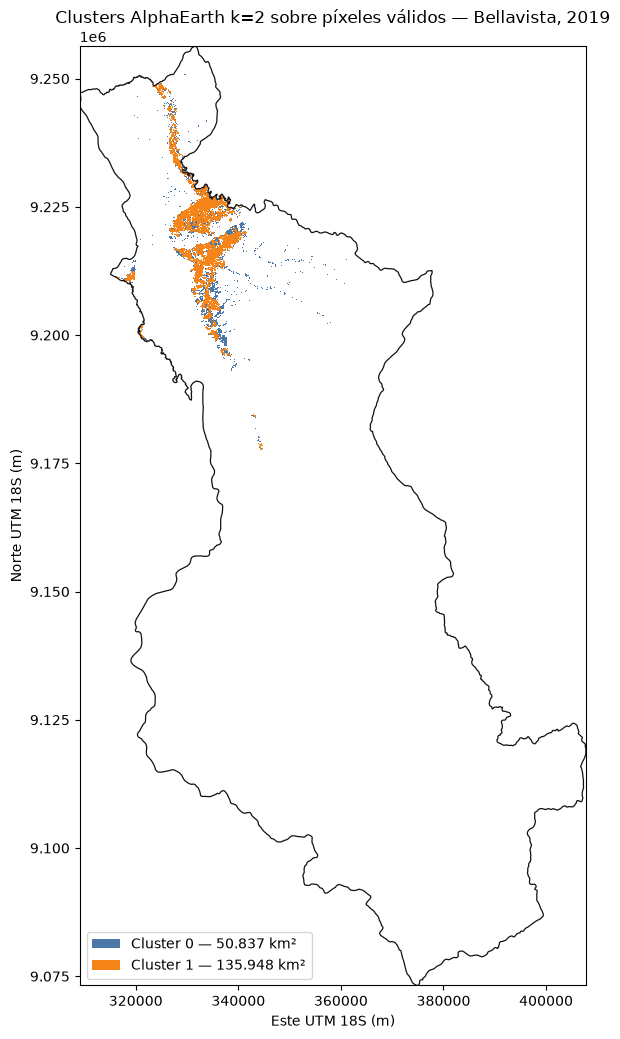

In [19]:
boundary = gpd.read_file(BOUNDARY_PATH)
with rasterio.open(CLUSTER_RASTER_PATH) as source:
    clusters = source.read(1, masked=True)
    raster_crs = source.crs
    bounds = source.bounds

boundary = boundary.to_crs(raster_crs)
cmap = ListedColormap(["#4C78A8", "#F58518"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
fig, ax = plt.subplots(figsize=(8.5, 10.5))
ax.imshow(
    clusters,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
)
boundary.boundary.plot(ax=ax, color="#111111", linewidth=0.9)
areas = phase3["areas"]["export_grid_30m"]["clusters"]
ax.legend(
    handles=[
        Patch(
            facecolor="#4C78A8",
            label=f"Cluster 0 — {areas['0']['area_km2_30m']:.3f} km²",
        ),
        Patch(
            facecolor="#F58518",
            label=f"Cluster 1 — {areas['1']['area_km2_30m']:.3f} km²",
        ),
    ],
    loc="lower left",
)
ax.set_title("Clusters AlphaEarth k=2 sobre píxeles válidos — Bellavista, 2019")
ax.set_xlabel("Este UTM 18S (m)")
ax.set_ylabel("Norte UTM 18S (m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## 13. GloRice-I

Pendiente. Se utilizarán `ex_phsc_2019.nc` e `in_phsc_2019.nc` después de la
aprobación correspondiente. **No se descargaron datos en esta fase.**

## 14. Clasificación rice/non-rice

Pendiente. La regla será `rice_proportion > 0.50`. **No ejecutado en esta fase.**

## 15. Incendios 2017–2019

Pendiente. Se utilizará VIIRS S-NPP Standard Processing. **No se descargaron ni
procesaron detecciones en esta fase.**

## 16. Normalización por área

Pendiente. Se reportarán conteos brutos, área fija por clase y detecciones por
100 km². **No ejecutado en esta fase.**

## 17. Resultados y discusión

Hasta la Fase 3, el resultado es una partición neutral del cropland válido en
dos clusters. A 10 m, las áreas analíticas son 50.842071 km² para Cluster 0 y
135.920586 km² para Cluster 1. En la cuadrícula categórica exportada a 30 m,
las áreas son 50.8365 y 135.9477 km², respectivamente.

El total a 30 m es 186.7842 km²: 0.021543 km² (aproximadamente 0.0115%) por
encima de la referencia analítica de 10 m. Esta diferencia pequeña se atribuye
a la representación categórica sobre una cuadrícula más gruesa. No se extrae
todavía ninguna conclusión agrícola.

## 18. Control de calidad

Además de los controles de muestra de Fase 1, la Fase 3 verificó una banda
`uint8`, CRS EPSG:32718, resolución 30 m, transform y bounds exactos, nodata
255, códigos válidos 0/1, COG con remuestreo de overviews por vecino más
cercano, suma exacta de 207,538 píxeles válidos y conservación bit a bit de las
etiquetas dentro de la máscara.

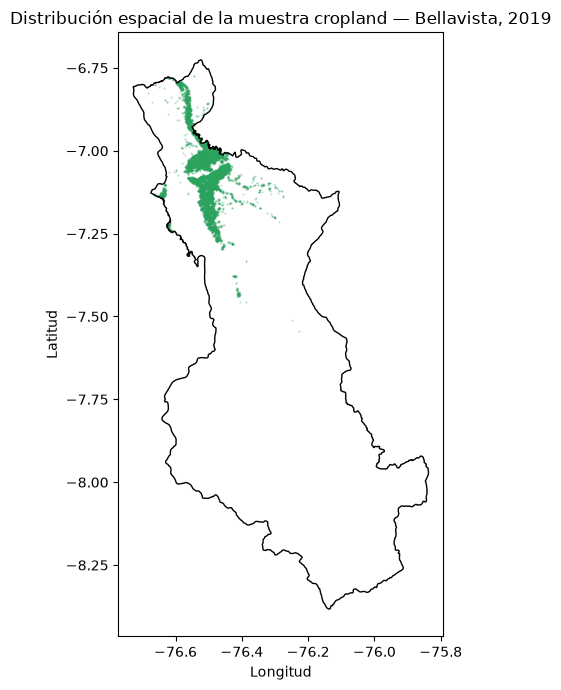

Validación de la muestra:
{
  "requested_rows": 10000,
  "actual_rows": 10000,
  "feature_columns": [
    "A00",
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09",
    "A10",
    "A11",
    "A12",
    "A13",
    "A14",
    "A15",
    "A16",
    "A17",
    "A18",
    "A19",
    "A20",
    "A21",
    "A22",
    "A23",
    "A24",
    "A25",
    "A26",
    "A27",
    "A28",
    "A29",
    "A30",
    "A31",
    "A32",
    "A33",
    "A34",
    "A35",
    "A36",
    "A37",
    "A38",
    "A39",
    "A40",
    "A41",
    "A42",
    "A43",
    "A44",
    "A45",
    "A46",
    "A47",
    "A48",
    "A49",
    "A50",
    "A51",
    "A52",
    "A53",
    "A54",
    "A55",
    "A56",
    "A57",
    "A58",
    "A59",
    "A60",
    "A61",
    "A62",
    "A63"
  ],
  "feature_column_count": 64,
  "exact_band_order": true,
  "null_values": 0,
  "all_finite": true,
  "cropmask_in_X": false,
  "coordinate_columns_in_X": false,
  "geometry_in_X": false,
  

sample_lon,0,1,2,3
sample_lat,,,,
0,0,0,72,2
1,73,1553,52,12
2,249,6177,511,46
3,357,896,0,0


Manifiesto: Assignments\Assignment2\cache_grupo3\manifests\phase1_manifest.json


In [7]:
X = sample_df[BANDS].copy()

validation = {
    "requested_rows": SAMPLE_SIZE,
    "actual_rows": int(len(sample_df)),
    "feature_columns": list(X.columns),
    "feature_column_count": int(X.shape[1]),
    "exact_band_order": list(X.columns) == BANDS,
    "null_values": int(X.isna().sum().sum()),
    "all_finite": bool(np.isfinite(X.to_numpy(dtype=np.float64)).all()),
    "cropmask_in_X": "cropmask" in X.columns,
    "coordinate_columns_in_X": bool(
        {"sample_lon", "sample_lat", "longitude", "latitude"} & set(X.columns)
    ),
    "geometry_in_X": "geometry" in X.columns,
    "identifier_columns_in_X": bool(
        {"id", "ID", "system:index", "index"} & set(X.columns)
    ),
    "exact_duplicate_embedding_rows": int(X.duplicated(keep=False).sum()),
}

if validation["actual_rows"] != SAMPLE_SIZE:
    raise RuntimeError("El número local de filas no coincide con el solicitado.")
if validation["feature_column_count"] != 64 or not validation["exact_band_order"]:
    raise RuntimeError("La matriz X no contiene exactamente A00–A63 en orden.")
if validation["null_values"] != 0 or not validation["all_finite"]:
    raise RuntimeError("La matriz X contiene valores nulos o no finitos.")
if any(
    validation[key]
    for key in (
        "cropmask_in_X",
        "coordinate_columns_in_X",
        "geometry_in_X",
        "identifier_columns_in_X",
    )
):
    raise RuntimeError("La matriz X contiene variables excluidas.")
if validation["exact_duplicate_embedding_rows"] != 0:
    raise RuntimeError(
        "Se detectaron filas de embeddings exactamente duplicadas; no se eliminaron."
    )

norms = np.linalg.norm(X.to_numpy(dtype=np.float64), axis=1)
norm_percentile_values = [0, 1, 5, 25, 50, 75, 95, 99, 100]
norm_percentiles = {
    str(percentile): float(np.percentile(norms, percentile))
    for percentile in norm_percentile_values
}
norm_summary = {
    "minimum": float(norms.min()),
    "maximum": float(norms.max()),
    "mean": float(norms.mean()),
    "standard_deviation": float(norms.std(ddof=0)),
    "percentiles": norm_percentiles,
    "renormalized": False,
}

non_cropland_sample_count = SAMPLE_SIZE - sample_cropland_count
if non_cropland_sample_count != 0:
    raise RuntimeError(
        f"{non_cropland_sample_count} puntos de muestra no están en WorldCover clase 40."
    )

boundary_gdf = geemap.ee_to_gdf(selected).to_crs("EPSG:4326")
sample_points_gdf = gpd.GeoDataFrame(
    sample_df[BANDS].copy(),
    geometry=gpd.points_from_xy(sample_df["sample_lon"], sample_df["sample_lat"]),
    crs="EPSG:4326",
)
region_geometry = boundary_gdf.geometry.union_all()
points_covered_by_region_exact = int(
    sample_points_gdf.geometry.covered_by(region_geometry).sum()
)
server_points_intersect_region_exact = int(
    sample_fc.filterBounds(geometry).size().getInfo()
)
server_points_intersect_region_5m = int(
    sample_fc.filterBounds(geometry.buffer(5)).size().getInfo()
)
if server_points_intersect_region_5m != SAMPLE_SIZE:
    raise RuntimeError(
        "Earth Engine reporta muestras a más de 5 m de la región de muestreo."
    )

# En el borde, la geometría del píxel de 10 m y la frontera vectorial pueden
# diferir por redondeo/reproyección. Se conserva el conteo exacto y se exige que
# todos los centros estén dentro de una tolerancia de medio píxel (5 m).
boundary_utm = boundary_gdf.to_crs(reference_crs)
sample_points_utm = sample_points_gdf.to_crs(reference_crs)
region_geometry_5m = boundary_utm.geometry.union_all().buffer(5)
points_covered_by_region_5m = int(
    sample_points_utm.geometry.covered_by(region_geometry_5m).sum()
)
if points_covered_by_region_5m != SAMPLE_SIZE:
    raise RuntimeError(
        "Existen muestras a más de 5 m de la geometría de Bellavista."
    )

lon_edges = np.linspace(sample_df["sample_lon"].min(), sample_df["sample_lon"].max(), 5)
lat_edges = np.linspace(sample_df["sample_lat"].min(), sample_df["sample_lat"].max(), 5)
lon_bin = pd.cut(
    sample_df["sample_lon"], bins=lon_edges, labels=False, include_lowest=True
)
lat_bin = pd.cut(
    sample_df["sample_lat"], bins=lat_edges, labels=False, include_lowest=True
)
spatial_grid_counts = (
    pd.crosstab(lat_bin, lon_bin)
    .reindex(index=range(4), columns=range(4), fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 7))
boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.0)
ax.scatter(
    sample_df["sample_lon"],
    sample_df["sample_lat"],
    s=2,
    alpha=0.35,
    color="#2ca25f",
    linewidths=0,
)
ax.set_title("Distribución espacial de la muestra cropland — Bellavista, 2019")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

files = {
    "csv": {
        "path": str(CSV_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
        "size_bytes": CSV_PATH.stat().st_size,
        "sha256": sha256_file(CSV_PATH),
    },
    "parquet": {
        "path": str(PARQUET_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
        "size_bytes": PARQUET_PATH.stat().st_size,
        "sha256": sha256_file(PARQUET_PATH),
    },
}

execution_time_seconds = time.perf_counter() - PHASE1_STARTED
memory = {
    "X_bytes": int(X.memory_usage(index=True, deep=True).sum()),
    "sample_dataframe_bytes": int(
        sample_df.memory_usage(index=True, deep=True).sum()
    ),
}

manifest = {
    "phase": "Assignment 2 - Phase 1",
    "executed_at_utc": EXECUTED_AT_UTC.isoformat(),
    "project_id": EE_PROJECT,
    "environment": environment_versions,
    "datasets": {
        "region": "FAO/GAUL/2015/level2",
        "alphaearth": ALPHAEARTH_DATASET,
        "worldcover": WORLDCOVER_DATASET,
    },
    "dates": {
        "alphaearth_start": START_DATE,
        "alphaearth_end_exclusive": END_DATE,
        "worldcover_year": 2021,
    },
    "region": REGION_SUMMARY,
    "alphaearth": ALPHAEARTH_SUMMARY,
    "cropland": CROPLAND_SUMMARY,
    "sampling": {
        "method": "ee.Image.stratifiedSample restricted to cropmask == 1",
        "download_method": download_method,
        "requested_samples": SAMPLE_SIZE,
        "server_samples": sample_server_count,
        "local_samples": len(sample_df),
        "scale_m": SAMPLE_SCALE_M,
        "seed": SAMPLE_SEED,
        "tile_scale": TILE_SCALE,
        "drop_nulls": True,
        "geometries_for_spatial_qc_only": True,
        "bands": BANDS,
        "stratified": True,
        "sample_mask_histogram": sample_mask_histogram,
    },
    "validation": {
        **validation,
        "non_cropland_sample_count": non_cropland_sample_count,
        "server_points_intersect_region_exact": server_points_intersect_region_exact,
        "server_points_intersect_region_5m": server_points_intersect_region_5m,
        "points_covered_by_region_exact": points_covered_by_region_exact,
        "points_covered_by_region_5m": points_covered_by_region_5m,
        "norms": norm_summary,
        "spatial_grid_counts_4x4": spatial_grid_counts.to_dict(),
    },
    "files": files,
    "memory": memory,
    "execution_time_seconds": execution_time_seconds,
}
MANIFEST_PATH.write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Validación de la muestra:")
print(json.dumps(validation, ensure_ascii=False, indent=2))
print("Resumen de normas:")
print(json.dumps(norm_summary, ensure_ascii=False, indent=2))
print("Conteos espaciales 4 × 4:")
display(spatial_grid_counts)
print(f"Manifiesto: {MANIFEST_PATH.relative_to(REPO_ROOT)}")

<!-- phase1-geometry-edge-validation -->
### Validación geométrica tolerante de borde

La auditoría de recuperación mantuvo el CRS original de las coordenadas
(`EPSG:4326`) y midió las distancias en la proyección de referencia de
AlphaEarth (`EPSG:32718`). De los 10,000 centros de píxel,
9,999 están dentro de la geometría exacta de Bellavista y
solo **1** (índice de muestra
`772`) aparece fuera por una
distancia submétrica:

- control local: máximo y percentiles 0, 25, 50, 75, 90, 95, 99 y 100 =
  `0.086381996228 m`;
- control autoritativo en Earth Engine: máximo y los mismos percentiles =
  `0.008638241444 m`;
- tolerancia aplicada: medio píxel de 10 m, es decir, **5.0 m**.

El punto coincide con un centro de la cuadrícula UTM de 10 m (residuo máximo
menor que 1 cm), su píxel intersecta Bellavista y Earth Engine confirmó que
pertenece a `WorldCover Map == 40`, posee las 64 bandas finitas y coincide
exactamente con el embedding guardado (diferencia máxima `0.0`). Por tanto,
se documenta como efecto normal de borde por reproyección/vectorización; el
punto se conserva y no se altera la región ni la muestra.

El detalle reproducible queda en
`Assignments/Assignment2/cache_grupo3/manifests/phase1_geometry_check.json`.


## 19. Inventario de entregables

In [20]:
inventory = pd.DataFrame(
    [
        {
            "artifact": "Notebook reproducible",
            "path": "Assignments/Assignment2/Assignment2_Identifying_Rice_Areas_grupo3.ipynb",
            "git_policy": "versionable",
        },
        {
            "artifact": "Clustergram k=1…11",
            "path": "Assignments/Assignment2/outputs_grupo3/clustergram_k_selection.png",
            "git_policy": "versionable",
        },
        {
            "artifact": "Muestra AlphaEarth CSV y Parquet",
            "path": "Assignments/Assignment2/cache_grupo3/raw/gee/",
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Ráster de clusters corregido",
            "path": str(CLUSTER_RASTER_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Exportación original conservada",
            "path": str(RAW_CLUSTER_RASTER_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no usar en análisis",
        },
        {
            "artifact": "Máscara auxiliar de validez",
            "path": str(VALID_MASK_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Límite GAUL de Bellavista",
            "path": str(BOUNDARY_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Manifiesto Fase 3",
            "path": str(PHASE3_MANIFEST_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
    ]
)
inventory


,artifact,path,git_policy
0,Notebook reproducible,Assignments/Assignment2/Assignment2_Identifyin...,versionable
1,Clustergram k=1…11,Assignments/Assignment2/outputs_grupo3/cluster...,versionable
2,Muestra AlphaEarth CSV y Parquet,Assignments/Assignment2/cache_grupo3/raw/gee/,cache local; no versionar
3,Ráster de clusters corregido,Assignments/Assignment2/cache_grupo3/derived/a...,cache local; no versionar
4,Exportación original conservada,Assignments/Assignment2/cache_grupo3/derived/a...,cache local; no usar en análisis
5,Máscara auxiliar de validez,Assignments/Assignment2/cache_grupo3/derived/a...,cache local; no versionar
6,Límite GAUL de Bellavista,Assignments/Assignment2/cache_grupo3/derived/b...,cache local; no versionar
7,Manifiesto Fase 3,Assignments/Assignment2/cache_grupo3/manifests...,cache local; no versionar
